# Where should the dye go? The Labelizer label score (LS) on T4 lysozyme

*The label-site score of Gebhardt et al., Nat. Commun. 16, 3305 (2025), natively
in `IMP.bff` (`ll_*` functions, PRD-120).*

Before any FRET pair can be chosen, someone has to decide **which residues can
carry a dye at all**. The Labelizer answers with one number per residue — the
**label score (LS)** — a weighted geometric mean over per-residue likelihood
ratios: how conserved the position is, how exposed it is, what secondary
structure it sits in, and how much the residue already resembles a cysteine.
Tryptophan proximity and charge environment are in the model at weight 0.

Two things worth knowing before reading the numbers:

* **A score is a likelihood ratio, not a probability.** Each term holds
  *P(labelable | observation) / P(labelable)*, so LS > 1 means the site is more
  labelable than the base rate, and LS is unbounded above.
* **Conservation is imported, never computed** here — an alignment and a rate
  estimate are a different program. T4 lysozyme ships without a ConSurf table,
  so the conservation term is dropped from the model, which is exactly what
  `imp_bff_labelizer --no-conservation` does. Under the full published model a
  missing grade would make every combined score `unavailable` instead.

The structure is the same T4 lysozyme as in `greedy_pair_selection.ipynb`
(`3GUN-processed.pdb`); its last section takes the step from sites to pairs
that the greedy notebook starts from. On the Labelizer's own worked example (1DDB) this port reproduces the
reference's secondary-structure and cysteine-resemblance terms exactly; see
`okf/validation/labelizer_ab.md`.

In [1]:
import numpy as np
import pylab as plt

import IMP.bff as bff

pdb = bff.get_example_path("structure") + "/T4L/3GUN-processed.pdb" 

## The structure, and the features the model scores

The features are computed natively: Kabsch–Sander secondary structure (the
reference shells out to the DSSP binary and refuses to start on macOS),
Shrake–Rupley solvent accessibility, residue depth, half-sphere exposure.

In [2]:
structure = bff.ll_read_structure(pdb)
print(f"{len(structure.residues)} residues, {len(structure.vdw)} atoms, "
      f"chains {sorted({r.chain for r in structure.residues})}")

secondary = bff.ll_dssp(structure)
rsa = np.asarray(bff.ll_relative_solvent_accessibility(
    structure, bff.LL_MAXASA_WILKE, 1.4, 590))
depth = np.asarray(bff.ll_residue_depth(structure, 1.4, 590))
hse = np.asarray(bff.ll_half_sphere_exposure(structure, 13.0)).reshape(-1, 2)

print("secondary structure: " + "  ".join(
    f"{s}={secondary.count(s)}" for s in sorted(set(secondary))))
print(f"RSA {rsa.mean():.2f} mean   depth {depth.min():.1f}-{depth.max():.1f} A")

162 residues, 2610 atoms, chains ['A']
secondary structure: -=22  B=4  E=8  G=3  H=101  S=12  T=12
RSA 0.26 mean   depth 1.4-7.2 A


## The model, and the one term T4 lysozyme cannot have

The published model weighs four terms at 1 and two at 0. Dropping `cs`
(conservation) is not an approximation of it — it is a different, smaller model,
stated here so the numbers say what they are.

In [3]:
model = bff.ll_model_paper()
print("published model: " + ", ".join(f"{p.tag}(w={p.weight})" for p in model))

model_t4l = [p for p in model if p.tag != "cs"]   # --no-conservation
print("T4 lysozyme:     " + ", ".join(f"{p.tag}(w={p.weight})" for p in model_t4l))

published model: cs(w=1), se(w=1), tp(w=0), cr(w=1), ss(w=1), ce(w=0)
T4 lysozyme:     se(w=1), tp(w=0), cr(w=1), ss(w=1), ce(w=0)


## The score

`ll_score_structure` runs features, parameters and the combination in one call
and returns tidy rows — one per (position, `score_type`), the shape the
`.mmfdb.pto` container stores. A position that cannot be scored carries a
`status` and **no value**; a position where any term is exactly zero is vetoed
to zero (the published exclusion rule).

In [4]:
scores = bff.ll_score_structure(pdb, model_t4l, bff.LlOptions())

combined = {bff.ll_residue_key(r.asym_id, r.seq_id): r.value
            for r in scores if r.score_type == "combined"}
statuses = {}
for r in scores:
    if r.score_type == "combined":
        statuses[r.status] = statuses.get(r.status, 0) + 1
print("combined statuses:", statuses)

print(f"\n{'rank':>4}  {'site':>6}  {'residue':>7}  {'LS':>7}")
for rank, (key, value) in enumerate(
        sorted(combined.items(), key=lambda kv: -kv[1])[:10], start=1):
    res = next(r for r in structure.residues
               if bff.ll_residue_key(r.chain, r.seq_id) == key)
    print(f"{rank:>4}  {key:>6}  {res.comp_id:>7}  {value:>7.4f}")

combined statuses: {'scored': 162}

rank    site  residue       LS
   1    A135      LYS   1.8906
   2     A83      LYS   1.8758
   3     A44      SER   1.8538
   4     A21      THR   1.8409
   5     A36      SER   1.8053
   6     A69      GLN   1.7852
   7     A52      ARG   1.7146
   8     A80      ARG   1.7012
   9     A48      LYS   1.6947
  10     A55      ASN   1.6893


## The picture: LS along the sequence, terms beside it

The upper panel is the answer to *where does the dye go*; the lower panel is
*why* — each model term at every position.

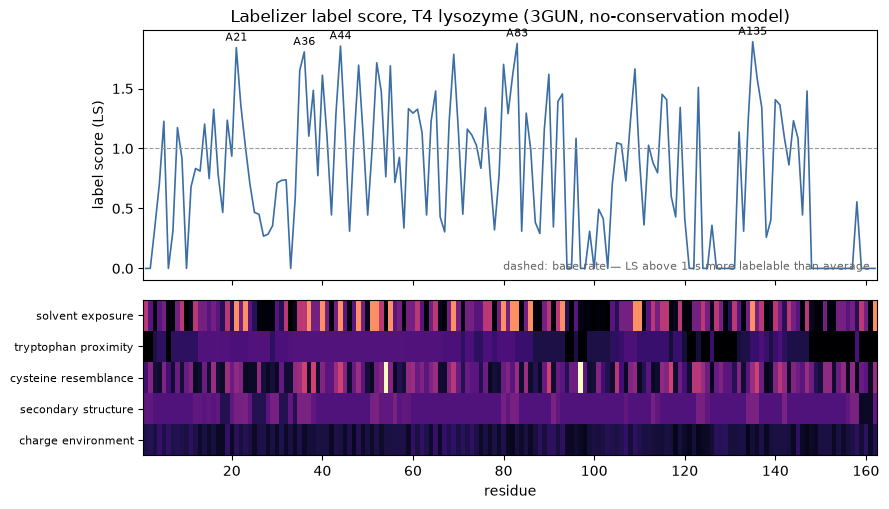

In [5]:
seq = [r.seq_id for r in structure.residues]
ls = [combined.get(bff.ll_residue_key(r.chain, r.seq_id), np.nan)
      for r in structure.residues]

# tidy rows -> (terms x residues) matrix for the lower panel
terms = [bff.ll_score_type(p.tag) for p in model_t4l]
grid = np.full((len(terms), len(seq)), np.nan)
for r in scores:
    if r.score_type in terms and r.status == "scored":
        grid[terms.index(r.score_type), seq.index(r.seq_id)] = r.value

best = sorted(combined.items(), key=lambda kv: -kv[1])[:5]

fig, (ax, bx) = plt.subplots(
    2, 1, figsize=(9, 5.2), sharex=True,
    gridspec_kw={"height_ratios": [1.6, 1.0]})
ax.plot(seq, ls, lw=1.2, color="#3b6ea5")
ax.axhline(1.0, color="0.6", lw=0.8, ls="--")
for key, value in best:
    i = seq.index(int(key[1:]))
    ax.annotate(key, (seq[i], value), textcoords="offset points",
                xytext=(0, 5), ha="center", fontsize=8)
ax.set_ylabel("label score (LS)")
ax.set_title("Labelizer label score, T4 lysozyme (3GUN, no-conservation model)")
ax.text(0.99, 0.04, "dashed: base rate — LS above 1 is more labelable than average",
        transform=ax.transAxes, ha="right", fontsize=8, color="0.4")

im = bx.imshow(grid, aspect="auto", cmap="magma",
               extent=[seq[0] - 0.5, seq[-1] + 0.5, len(terms) - 0.5, -0.5])
bx.set_yticks(range(len(terms)), [t.replace("_", " ") for t in terms], fontsize=8)
bx.set_xlabel("residue")
fig.tight_layout()
fig.savefig("labelizer_score.png", dpi=150)
plt.show()

## The score on the structure

The same numbers on the fold: the structure is written back with LS in the
B-factor column (the convention chisurf and PyMOL read — `3GUN_LS.pdb`, written
beside this notebook), and embedded below as an interactive 3Dmol.js view
(py3Dmol; the model data lives in the notebook, the viewer script loads from its
CDN when the cell renders). The cartoon is colored by LS, stretched between this
structure's min and max — **red is high**, blue is low — and the five best sites
are drawn as black spheres with labels.

In [6]:
out_pdb = "3GUN_LS.pdb"
with open(pdb) as fin, open(out_pdb, "w") as fout:
    for line in fin:
        if line.startswith("ATOM"):
            value = combined.get(bff.ll_residue_key(line[21], int(line[22:26])))
            if value is not None:
                line = line[:60] + f"{value:6.2f}" + line[66:]   # B-factor column
        fout.write(line)
print(f"{out_pdb}: LS {min(combined.values()):.2f}-{max(combined.values()):.2f} "
      f"in the B-factor column")

import py3Dmol
top5 = [k for k, _ in sorted(combined.items(), key=lambda kv: -kv[1])[:5]]

view = py3Dmol.view(width=760, height=480)
view.addModel(open(out_pdb).read(), "pdb")
# 'rwb' maps min->red; the range is reversed so the high end is red
view.setStyle({"cartoon": {"colorscheme": {"prop": "b", "gradient": "rwb",
                                           "min": max(combined.values()),
                                           "max": min(combined.values())}}})
view.addStyle({"resi": ",".join(k[1:] for k in top5)},
              {"sphere": {"radius": 2.8, "color": "black"}})
for k in top5:
    view.addLabel(k, {"position": {"resi": int(k[1:])}, "fontSize": 11,
                      "fontColor": "white", "background": "black",
                      "showBackground": True})
view.zoomTo()
view.show()

3GUN_LS.pdb: LS 0.00-1.89 in the B-factor column


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Which of these sites make a pair

The LS ranks *sites*; an experiment measures *pairs*. `ll_pair_scores` screens
every pair of labelable sites with the reference's analytic alpha cone, then
rebuilds the best few dye positions with a real accessible volume (probe model
`accessible_volume`, `n_refine` pairs per site). The cone systematically
over-reaches, which is why the pairs it ranked highest are not always the ones
that survive the rebuild — and why the distance should sit near R0, where FRET
responds to change.

In [7]:
options = bff.LlFretOptions()
options.forster_radius = 52.0      # Alexa Fluor 488 - Alexa Fluor 647 ballpark
options.n_refine = 5

pairs = list(bff.ll_pair_scores(pdb, combined, options))
print(f"{len(pairs)} pairs above the LS threshold; best of them")
print(f"{'site 1':>8} {'site 2':>8} {'pair score':>11} {'d / A':>7}  dye placed by")
for p in pairs[:8]:
    how = ("AV" if p.probe_model == bff.PROBE_MODEL_ACCESSIBLE_VOLUME else "cone")
    print(f"{p.asym_id_1}{p.seq_id_1:>4} {p.asym_id_2}{p.seq_id_2:>5}  "
          f"{p.value:>11.4f} {p.distance:>7.1f}  {how}")

4560 pairs above the LS threshold; best of them
  site 1   site 2  pair score   d / A  dye placed by
A  44 A   90       1.5888    53.5  AV
A  44 A   92       1.5329    52.8  cone
A  48 A  123       1.5287    51.2  cone
A  52 A  135       1.4936    55.1  AV
A  55 A   93       1.4844    51.1  cone
A  55 A  135       1.4755    49.0  cone
A  38 A  123       1.4583    51.6  cone
A  38 A   90       1.4514    50.9  cone


## Parity check: against the labelizer.org webserver

The same structure through [labelizer.org](https://labelizer.org), the paper's
own webserver, scored with its single-structure labelling analysis. The cell
below re-creates the webserver's exact submission (upload → job → poll → CSV);
the result file it fetched is cached beside this notebook, so re-running here
does not hit the server again. Provenance: job `b6957587-94dd-4727-95bf-a5ca01a34264`,
labelizer.org, 2026-09-09.

What to expect, and why this is parity, not identity:

- **CR and SS agree** (CR on all 162 residues; SS on 156 — six helix/turn
  boundary calls differ).
- **SE agrees on 107 of 162**: the binned score is the same table, but the two
  engines place a residue in different bins when its SASA sits near a bin edge
  — this port uses Shrake–Rupley, the webserver its own SASA pipeline.
- **The combined LS is the corrected arithmetic here.** The webserver evaluates
  neither tryptophan proximity nor charge environment ("coming soon" in its UI),
  so no weight-0 term can veto its LS — which is what `LL_MODEL_CORRECTED`
  computes. The published model adds the 34 zero-vetoed sites on top.
- Its short `*_LS.csv` summary drops rows; `*_LSlong.csv` is complete — this
  compares against the long file.

In [8]:
import pathlib, time
WEBSERVER_CSV = "3GUN_LS_LSlong.csv"

if not pathlib.Path(WEBSERVER_CSV).exists():
    import uuid
    import requests

    B = "https://labelizer.org/backend/"
    s = requests.Session()
    s.headers["User-Agent"] = "IMP.bff labelizer example (parity check)"

    # 1. upload: ATOM records, plus the chain letter and an id of our choosing
    payload = "".join(l for l in open(pdb) if l.startswith(("ATOM", "TER", "END")))
    uploaded = s.post(B + "load_pdb", json={
        "chains": "A", "pdbID": "3GUN_LS", "payload": payload}, timeout=60).json()

    # 2. the analysis job -- the payload the web app itself posts
    data = {
        "uuid": str(uuid.uuid4()), "analysisName": "bff-parity", "email": "",
        "analysisMode": "LABELLING_ONE_FLUOROPHORE_ONE_STRUCTURE",
        "proteinId1": uploaded["id"], "protein1": "", "pdbId1": "3GUN_LS",
        "dbName1": "CUSTOM", "selectableChainString1": "A", "selectedChain1": "A",
        "fluorophore1": "", "fluorophore2": "",
        "advancedParameters": {n: {"name": n, "file_tag": t, "sensitivity": "medium",
                                   "weight": "normal", "used": True}
            for n, t in [("Conservation score", "cs"), ("Solvent exposure", "se"),
                         ("Cysteine resemblance", "cr"), ("Secondary structure", "ss")]},
    }
    job = s.post(B + "analysis", json=data, timeout=60).json()["jobId"]
    print(f"submitted {job} -- the webserver queues jobs, this takes minutes")

    while "files" not in (status := s.get(f"{B}analysis/{job}", timeout=30).json()):
        time.sleep(15)
    print(status["files"])

    (pathlib.Path(WEBSERVER_CSV)
     .write_text(s.get(f"{B}analysis/{job}/3GUN_LS_LSlong.csv", timeout=60).text))

import pandas as pd
web = pd.read_csv(WEBSERVER_CSV)
print(f"{len(web)} scored positions from the webserver")

162 scored positions from the webserver


The comparison, in one table and one picture: native against webserver,
residue for residue.

solvent_exposure       identical on 107/162
cysteine_resemblance   identical on 162/162
secondary_structure    identical on 156/162
combined LS            identical on 104/162, median |diff| 0.0000, max 0.603


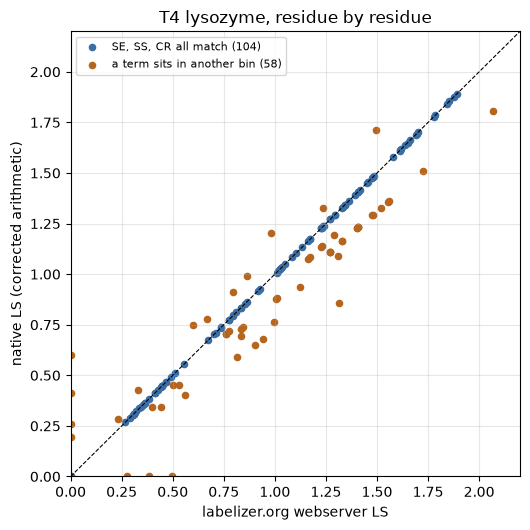

In [9]:
# the arithmetic the webserver's LS implements: no weight-0 veto
opts = bff.LlOptions(); opts.model = bff.LL_MODEL_CORRECTED
parity = bff.ll_score_structure(pdb, model_t4l, opts)
par = {bff.ll_residue_key(r.asym_id, r.seq_id): r.value for r in parity
       if r.score_type == "combined"}
term = {(r.seq_id, r.score_type): r.value for r in parity
        if r.score_type != "combined"}

y = np.array([par[k] for k in web.ID])
x = web["Labeling Score"].values
same = {t: np.isclose([term[(int(k[1:]), t)] for k in web.ID],
                      web[c].values, atol=1e-9)
        for t, c in [("solvent_exposure", "SE"), ("cysteine_resemblance", "CR"),
                     ("secondary_structure", "SS")]}
for t, m in same.items():
    print(f"{t:<22} identical on {m.sum():>3}/{len(web)}")

all_same = np.logical_and.reduce(list(same.values()))
d = np.abs(x - y)
print(f"combined LS            identical on {int(np.isclose(x, y, atol=1e-9).sum()):>3}/{len(web)}, "
      f"median |diff| {np.median(d):.4f}, max {d.max():.3f}")

fig, ax = plt.subplots(figsize=(5.4, 5.4))
lim = (0, 2.2)
ax.plot(lim, lim, "k--", lw=0.8)
ax.scatter(x[all_same], y[all_same], s=20, color="#3b6ea5",
           label=f"SE, SS, CR all match ({all_same.sum()})")
ax.scatter(x[~all_same], y[~all_same], s=20, color="#b5651d",
           label=f"a term sits in another bin ({(~all_same).sum()})")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("labelizer.org webserver LS")
ax.set_ylabel("native LS (corrected arithmetic)")
ax.set_title("T4 lysozyme, residue by residue")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Reading the results

- The **best sites** (135, 83, 44, ...) are surface residues: the solvent
  exposure and cysteine-resemblance terms dominate, which is what "labelable"
  means.
- **The zeros are the published zero-veto, not "unlabelable".** Any term that
  comes out exactly zero vetoes the site — and under the published arithmetic
  that includes terms of weight 0. Here it is the tryptophan-proximity term that
  zeroes 34 of the 162 sites whose remaining terms are all fine. Scored again
  with `LlOptions(model=bff.LL_MODEL_CORRECTED)` — the arithmetic the
  reference's own documentation describes, which vetoes only weighted terms —
  5 sites stay zero, 29 change value, and the top of the ranking does not move.
- **LS is comparative.** It ranks the sites of *this* structure against *this*
  structure's base rate; an LS of 1.9 does not mean "90% labelable".
- **This is the no-conservation model.** With a ConSurf table
  (`ll_score_structure(..., conservation_path)`) the `cs` term joins at weight 1
  and the ranking can change; everything else about the arithmetic is the
  published one, defects included.
- From here: feed the top sites to `greedy_pair_selection.ipynb`, which asks the
  next question — which *pairs* to actually measure, and how many it takes until
  resolution stops improving.

## The conservation term, on the paper's worked example (1DDB)

Everything above dropped conservation — T4 lysozyme has no ConSurf grades, and
none are reachable today: the labelizer.org API accepts the conservation toggle
but its output comes back without the `cs` file for every entry tried (3GUN and
1DDB, custom upload and PDB-database load alike), its REST surface exposes no
grades endpoint, and the precomputed ConSurfDB host it cites is unreachable.

What the repository *does* ship is the reference distribution's own ConSurf
output for the paper's worked example — mouse BID, PDB **1DDB**, model 39,
chain A (`test/input/labelizer/1DDB-conservationscore-39-A.pdb`: 195 residues,
187 distinct grades, the normalised grade in the B-factor column, exactly the
file `ll_read_consurf` reads). Nothing to download. With it, the full published
model runs — conservation at weight 1 beside exposure, cysteine resemblance and
secondary structure.

In [10]:
pdb_1ddb = "../../test/input/labelizer/1DDB-39.pdb"
grades = "../../test/input/labelizer/1DDB-conservationscore-39-A.pdb"

full_model = bff.ll_model_paper()          # cs(w=1), se(w=1), tp(0), cr(w=1), ss(w=1), ce(0)
scores_cs = bff.ll_score_structure(pdb_1ddb, full_model, bff.LlOptions(), grades)

comb_cs = {bff.ll_residue_key(r.asym_id, r.seq_id): r.value
           for r in scores_cs if r.score_type == "combined"}
status = {}
for r in scores_cs:
    if r.score_type == "combined":
        status[r.status] = status.get(r.status, 0) + 1
print(f"{len(comb_cs)} positions scored with the full model; statuses {status}")
print(f"conservation term: {sum(1 for r in scores_cs if r.score_type == 'conservation' and r.status == 'scored')} rows")

print(f"\n{'rank':>4}  {'site':>6}  {'LS':>7}")
for rank, (key, value) in enumerate(
        sorted(comb_cs.items(), key=lambda kv: -kv[1])[:10], start=1):
    print(f"{rank:>4}  {key:>6}  {'':>7}  {value:>7.4f}")

195 positions scored with the full model; statuses {'scored': 195}
conservation term: 195 rows

rank    site       LS
   1     A30            2.0132
   2     A66            1.9492
   3     A69            1.9004
   4      A3            1.8632
   5      A4            1.7556
   6     A68            1.7537
   7     A33            1.7279
   8    A104            1.7051
   9     A51            1.6846
  10     A73            1.6733


grade range -1.24..3.10 over 195 residues
top-10 overlap with/without conservation: 3/10


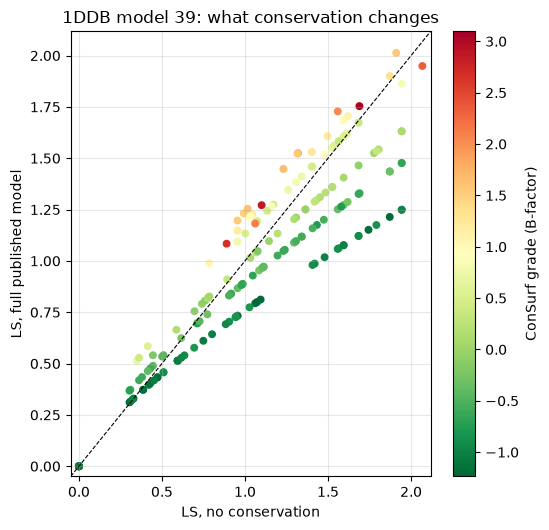

In [11]:
# with vs without: how much the conservation term moves the answer
scores_ncs = bff.ll_score_structure(
    pdb_1ddb, [p for p in full_model if p.tag != "cs"], bff.LlOptions())
comb_ncs = {bff.ll_residue_key(r.asym_id, r.seq_id): r.value
            for r in scores_ncs if r.score_type == "combined"}

grades_map = bff.ll_read_consurf(grades)
keys = sorted(set(comb_cs) & set(comb_ncs), key=lambda k: int(k[1:]))
x = np.array([comb_ncs[k] for k in keys])          # no conservation
y = np.array([comb_cs[k] for k in keys])           # full published model
g = np.array([grades_map[k] for k in keys])        # the ConSurf grade itself
print(f"grade range {g.min():.2f}..{g.max():.2f} over {len(keys)} residues")

rank_c = {k: i for i, k in enumerate(sorted(keys, key=lambda k: -comb_cs[k]))}
rank_n = {k: i for i, k in enumerate(sorted(keys, key=lambda k: -comb_ncs[k]))}
top_c = set(sorted(comb_cs, key=comb_cs.get, reverse=True)[:10])
top_n = set(sorted(comb_ncs, key=comb_ncs.get, reverse=True)[:10])
print(f"top-10 overlap with/without conservation: {len(top_c & top_n)}/10")

fig, ax = plt.subplots(figsize=(5.6, 5.4))
lim = (min(x.min(), y.min()) - 0.05, max(x.max(), y.max()) + 0.05)
ax.plot(lim, lim, "k--", lw=0.8)
sc = ax.scatter(x, y, c=g, cmap="RdYlGn_r", s=22)
fig.colorbar(sc, ax=ax, label="ConSurf grade (B-factor)")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("LS, no conservation")
ax.set_ylabel("LS, full published model")
ax.set_title("1DDB model 39: what conservation changes")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

**Reading the conservation comparison**

- Conservation **reshapes the ranking**: only 3 of the top-10 sites survive
  from the no-conservation model. Variable positions rise (a site moving from
  rank 108 to 55 is typical), conserved ones sink — a residue the evolutionary
  record says is functionally constrained is a poor place to force a dye.
- The colour carries the mechanism: high-ConSurf-grade (variable) residues sit
  above the diagonal, conserved ones below.
- **A trap this section avoids, for the record**: the *other* shipped file,
  `1DDB-39_cs.pdb`, is the reference example's own *output* — re-running its
  example feeds that back as grades, landing in a two-cycle with just two
  distinct values. The lookup reproduces that degenerate pair to all sixteen
  digits (`test_the_conservation_lookup_is_exact_to_the_last_digit`), which is
  how the conservation machinery is verified without a reproducible reference
  input; `test_the_shipped_conservation_reference_is_degenerate` guards the
  story. See `okf/validation/labelizer_ab.md`.
- Should labelizer.org's conservation pipeline come back (its analysis emits a
  `*_cs.csv` when the internal ConSurf job succeeds — none of ours did), the
  same parity treatment as the SE/CR/SS section above applies unchanged.